# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test8 solver

Notebook equivalent of `tests/6_mceq/test8_solver.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `mceq` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `mceq` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test8_solver"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "6_mceq" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\6_mceq\test8_solver.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `mceq` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "mceq" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\mceq\test8_solver


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_interpolate_flux_at_Xobs_shape`

**What is checked:** Interpolate flux at xobs shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_interpolate_flux_at_Xobs_shape)


Running test_interpolate_flux_at_Xobs_shape ...
flux_XE shape: torch.Size([50, 3])
phi shape    : torch.Size([3])
------------------------------------------------------------------------------------------
PASSED: test_interpolate_flux_at_Xobs_shape


## Test: `test_interpolate_flux_at_grid_point_matches_value`

**What is checked:** Interpolate flux at grid point matches value behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: 0.0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_interpolate_flux_at_grid_point_matches_value)


Running test_interpolate_flux_at_grid_point_matches_value ...
X_obs: 426.3265306122449
max difference: 0.0
------------------------------------------------------------------------------------------
PASSED: test_interpolate_flux_at_grid_point_matches_value


## Test: `test_interpolate_flux_at_Xobs_rejects_outside_range`

**What is checked:** Interpolate flux at xobs rejects outside range behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_interpolate_flux_at_Xobs_rejects_outside_range)


Running test_interpolate_flux_at_Xobs_rejects_outside_range ...
------------------------------------------------------------------------------------------
PASSED: test_interpolate_flux_at_Xobs_rejects_outside_range


## Test: `test_interpolate_flux_at_Xobs_rejects_bad_flux_shape`

**What is checked:** Interpolate flux at xobs rejects bad flux shape behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_interpolate_flux_at_Xobs_rejects_bad_flux_shape)


Running test_interpolate_flux_at_Xobs_rejects_bad_flux_shape ...
------------------------------------------------------------------------------------------
PASSED: test_interpolate_flux_at_Xobs_rejects_bad_flux_shape


## Test: `test_interpolate_flux_at_Xobs_rejects_non_monotonic_X`

**What is checked:** Interpolate flux at xobs rejects non monotonic x behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_interpolate_flux_at_Xobs_rejects_non_monotonic_X)


Running test_interpolate_flux_at_Xobs_rejects_non_monotonic_X ...
------------------------------------------------------------------------------------------
PASSED: test_interpolate_flux_at_Xobs_rejects_non_monotonic_X


## Test: `test_get_mceq_flux_at_Xobs_shapes`

**What is checked:** Get mceq flux at xobs shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [9]:
run_notebook_test(TEST_MODULE.test_get_mceq_flux_at_Xobs_shapes)


Running test_get_mceq_flux_at_Xobs_shapes ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
E_grid shape: torch.Size([121])
phi_E shape : torch.Size([121])
E min/max   : 0.08912509381337455 89125093813.37459
phi min/max : 0.0 1.3140325107746735
------------------------------------------------------------------------------------------
PASSED: test_get_mceq_flux_at_Xobs_shapes


## Test: `test_get_mceq_flux_at_Xobs_positive_and_finite`

**What is checked:** Get mceq flux at xobs positive and finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [10]:
run_notebook_test(TEST_MODULE.test_get_mceq_flux_at_Xobs_positive_and_finite)


Running test_get_mceq_flux_at_Xobs_positive_and_finite ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
has nan: False
has inf: False
min phi: 0.0
------------------------------------------------------------------------------------------
PASSED: test_get_mceq_flux_at_Xobs_positive_and_finite


## Test: `test_solve_flux_vs_depth_grid_shapes`

**What is checked:** Solve flux vs depth grid shapes behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_solve_flux_vs_depth_grid_shapes)


Running test_solve_flux_vs_depth_grid_shapes ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
X_out shape : torch.Size([8])
E_grid shape: torch.Size([121])
flux shape  : torch.Size([8, 121])
------------------------------------------------------------------------------------------
PASSED: test_solve_flux_vs_depth_grid_shapes


## Test: `test_solve_flux_vs_depth_grid_positive_and_finite`

**What is checked:** Solve flux vs depth grid positive and finite behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; solver tests may fail when optional external MCEq data or packages are not installed.


In [12]:
run_notebook_test(TEST_MODULE.test_solve_flux_vs_depth_grid_positive_and_finite)


Running test_solve_flux_vs_depth_grid_positive_and_finite ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
flux min: 0.0
flux max: 1.3140320286084712
------------------------------------------------------------------------------------------
PASSED: test_solve_flux_vs_depth_grid_positive_and_finite


## Test: `test_solve_flux_vs_depth_grid_rejects_non_monotonic_X`

**What is checked:** Solve flux vs depth grid rejects non monotonic x behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_raises.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [13]:
run_notebook_test(TEST_MODULE.test_solve_flux_vs_depth_grid_rejects_non_monotonic_X)


Running test_solve_flux_vs_depth_grid_rejects_non_monotonic_X ...
------------------------------------------------------------------------------------------
PASSED: test_solve_flux_vs_depth_grid_rejects_non_monotonic_X


## Test: `test_interpolated_Xobs_matches_direct_solution_reasonably`

**What is checked:** Interpolated xobs matches direct solution reasonably behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check.


In [14]:
run_notebook_test(TEST_MODULE.test_interpolated_Xobs_matches_direct_solution_reasonably)


Running test_interpolated_Xobs_matches_direct_solution_reasonably ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to 

## Plot: `plot_flux_vs_depth_for_selected_energies()`

**What is checked:** Flux vs depth for selected energies behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_flux_vs_depth_for_selected_energies()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_flux_vs_depth_for_selected_energies_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_flux_vs_depth_for_selected_energies() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Saved plot: V:\output\test\mceq\test8_solver\plot_flux_vs_depth_for_selected_energies_figure_001.png


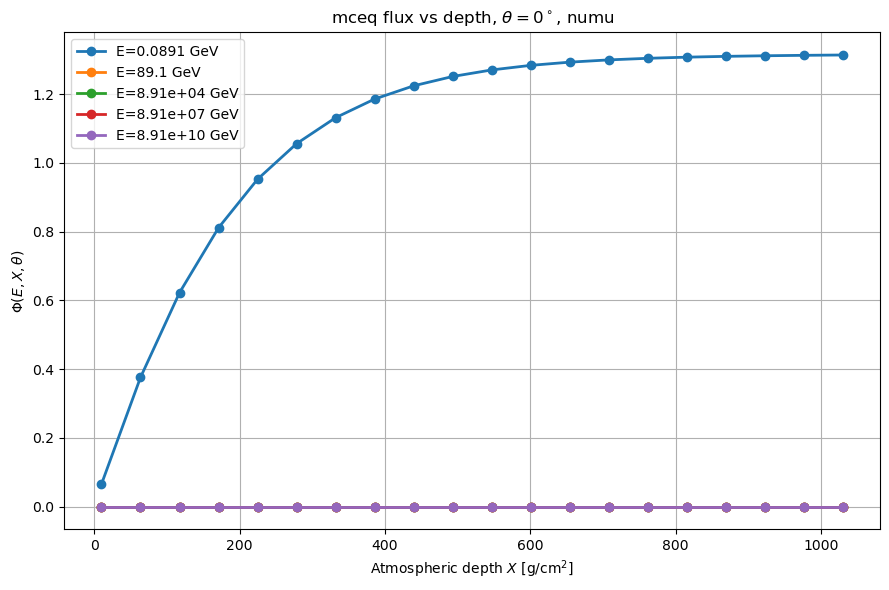

PASSED: plot_flux_vs_depth_for_selected_energies()


In [15]:
run_notebook_call('plot_flux_vs_depth_for_selected_energies()', lambda: TEST_MODULE.plot_flux_vs_depth_for_selected_energies())


## Plot: `plot_observer_flux_spectrum()`

**What is checked:** Observer flux spectrum behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_observer_flux_spectrum()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_observer_flux_spectrum_figure_001.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_observer_flux_spectrum() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun

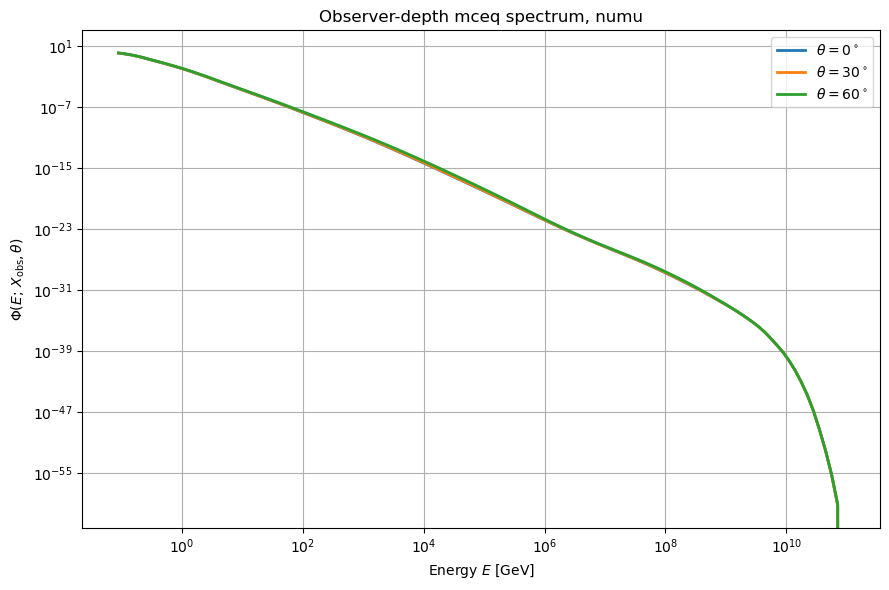

PASSED: plot_observer_flux_spectrum()


In [16]:
run_notebook_call('plot_observer_flux_spectrum()', lambda: TEST_MODULE.plot_observer_flux_spectrum())


## Plot: `plot_direct_vs_interpolated_Xobs()`

**What is checked:** Direct vs interpolated xobs behavior and numerical consistency.

**Expected result:** The expected result is that the diagnostic plot call completes and writes its figure output to `OUTPUT_DIR`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; optional MCEq/crflux dependencies or atmospheric-model availability can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `plot_direct_vs_interpolated_Xobs()`

This block generates or validates files in `OUTPUT_DIR`:

- `plot_direct_vs_interpolated_Xobs_figure_001.png`
- `plot_direct_vs_interpolated_Xobs_figure_002.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_direct_vs_interpolated_Xobs() ...
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MC

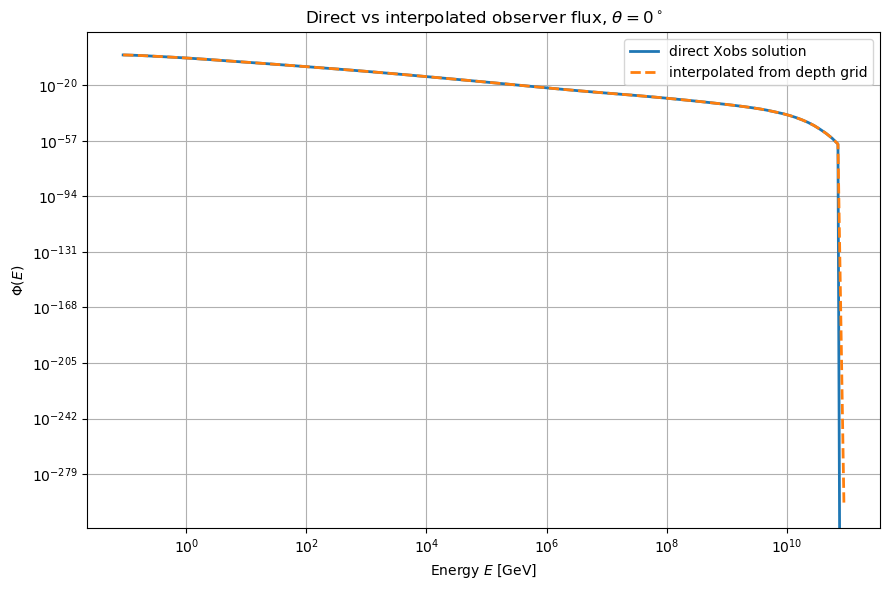

Saved plot: V:\output\test\mceq\test8_solver\plot_direct_vs_interpolated_Xobs_figure_002.png


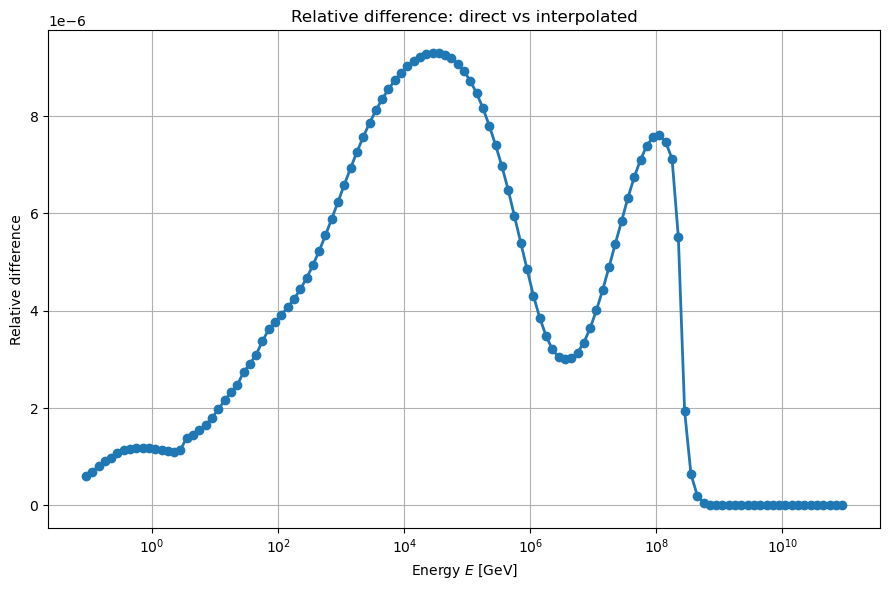

PASSED: plot_direct_vs_interpolated_Xobs()


In [17]:
run_notebook_call('plot_direct_vs_interpolated_Xobs()', lambda: TEST_MODULE.plot_direct_vs_interpolated_Xobs())
